# Unveiling Mushroom Mysteries: A Python-Powered Machine Learning Journey

**Module:** Predictive Analytics and Machine Learning using Python
**Section 2:** Exploratory Data Analysis and Classification on the Mushroom dataset

Dataset: [github.com/usmanakhtar/Mushrooms-dataset](https://github.com/usmanakhtar/Mushrooms-dataset)

**Ethical note:** this dataset is a public dataset released for research and teaching (Schlimmer, 1987) and contains no personal or sensitive data, so no ethical approval was needed to use it.

In [22]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


## Q5. Exploratory Data Analysis

In [23]:
import os, subprocess

if not os.path.exists("mushrooms.csv"):
    subprocess.run(["git", "clone", "https://github.com/usmanakhtar/Mushrooms-dataset.git"], check=False)
    if os.path.exists("Mushrooms-dataset/mushrooms.csv"):
        import shutil
        shutil.copy("Mushrooms-dataset/mushrooms.csv", "mushrooms.csv")

df = pd.read_csv("mushrooms.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [25]:
summary = df.describe()
display(summary)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [26]:
# Check for missing values
print("Missing values (NaN) per column:")
print(df.isnull().sum().sum(), "in total")

# This dataset marks missing values with '?' instead of leaving them blank
print()
print("Columns using '?' for missing values:")
print((df == "?").sum()[(df == "?").sum() > 0])

Missing values (NaN) per column:
0 in total

Columns using '?' for missing values:
stalk-root    2480
dtype: int64


class
e    4208
p    3916
Name: count, dtype: int64


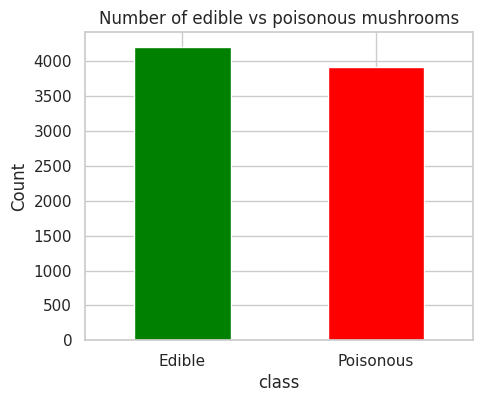

In [27]:
print(df["class"].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
df["class"].map({"e": "Edible", "p": "Poisonous"}).value_counts().plot(kind="bar", color=["green", "red"], ax=ax)
ax.set_title("Number of edible vs poisonous mushrooms")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The two classes are fairly balanced (about 52% edible, 48% poisonous), so accuracy is a fair metric to use later.

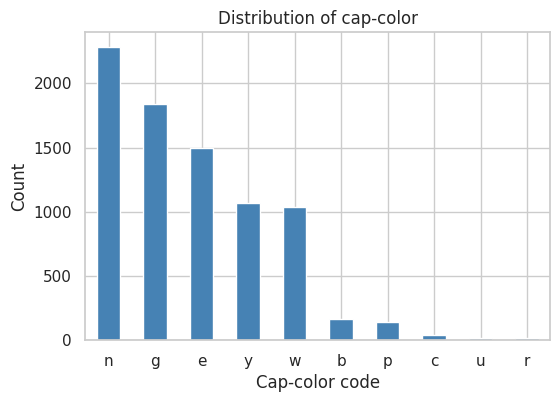

In [28]:
# Distribution of a single feature (cap-color), to see how common each category is
fig, ax = plt.subplots(figsize=(6, 4))
df["cap-color"].value_counts().plot(kind="bar", color="steelblue", ax=ax)
ax.set_title("Distribution of cap-color")
ax.set_xlabel("Cap-color code")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.show()

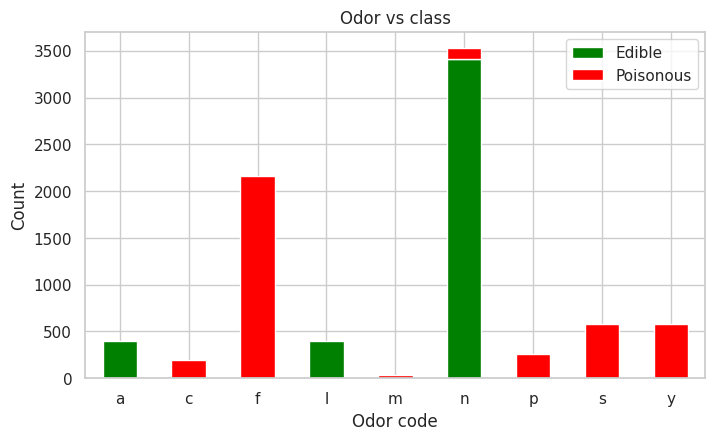

In [29]:
fig, ax = plt.subplots(figsize=(8, 4.5))
pd.crosstab(df["odor"], df["class"]).plot(kind="bar", stacked=True, ax=ax, color=["green", "red"])
ax.set_title("Odor vs class")
ax.set_xlabel("Odor code")
ax.set_ylabel("Count")
ax.legend(["Edible", "Poisonous"])
plt.xticks(rotation=0)
plt.show()

## Q6. Classification models

In [30]:
df_enc = df.copy()
encoders = {}
for col in df_enc.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le

X = df_enc.drop(columns=["class"])
y = df_enc["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 6093
Test rows: 2031


In [31]:
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Classifier": SVC(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

print("Models to try:", list(models.keys()))

Models to try: ['Gaussian Naive Bayes', 'Random Forest', 'Decision Tree', 'Logistic Regression', 'Support Vector Classifier', 'K-Nearest Neighbors', 'Gradient Boosting']


In [32]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,1.0000,1.0000,1.0000,1.0000
1,Decision Tree,1.0000,1.0000,1.0000,1.0000
2,Gradient Boosting,1.0000,1.0000,1.0000,1.0000
3,K-Nearest Neighbors,0.9980,0.9959,1.0000,0.9980
4,Support Vector Classifier,0.9916,0.9979,0.9847,0.9913
5,Logistic Regression,0.9552,0.9568,0.9499,0.9534
6,Gaussian Naive Bayes,0.9222,0.9028,0.9397,0.9209


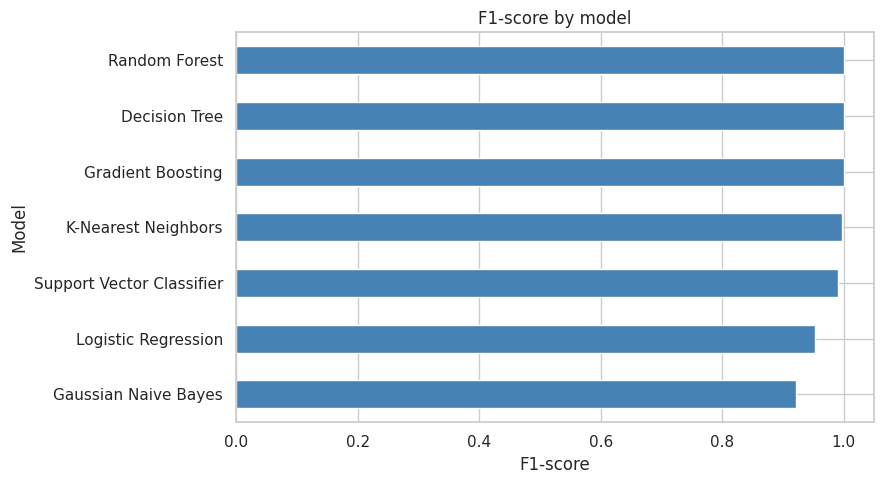

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df.set_index("Model")["F1-score"].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("F1-score")
ax.set_title("F1-score by model")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

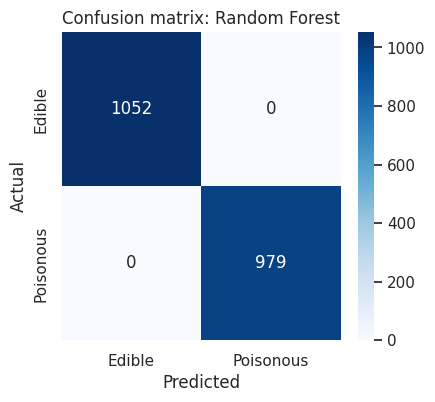

Best model on this test set: Random Forest


In [34]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
cm = confusion_matrix(y_test, best_model.predict(X_test))

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Edible", "Poisonous"], yticklabels=["Edible", "Poisonous"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix: {best_name}")
plt.show()

print("Best model on this test set:", best_name)